> **🤖 AI-coded.** This notebook is part of an **AI-coded extension of [Dynestyx](https://github.com/BasisResearch/dynestyx)** that adds factorial state-space models (fSSMs) — a `dynestyx`-based counterpart to [`cuthberto-carlos`](https://github.com/state-space-models/cuthberto-carlos), built on [`cuthbert`](https://github.com/state-space-models/cuthbert). It reproduces the online skill-rating models of [Duffield et al. (2024)](https://doi.org/10.1093/jrsssc/qlae035). See the [project README](https://github.com/DanWaxman/dynestyx) for an overview.

# Reproducing Duffield et al. (2024) — Chess

This deep dive reproduces the **chess** results of

> Duffield, Power, Wadsworth et al. (2024), *A state-space perspective on modelling and inference for online skill rating*, **JRSS-C 73(5):1262–1282** ([code: `SamDuffield/abile`](https://github.com/SamDuffield/abile)),

using dynestyx's factorial state-space model. We rate the world's top chess players from **Candidates-cycle games (2016–2019)** treated as an online skill-rating problem.

**Model.** Each player has a scalar latent *skill* that follows a Brownian random walk; a game's outcome (white win / draw / black win) is a sigmoidal function of the skill difference with a draw margin $\varepsilon$ — exactly the dynestyx `MatchOutcomeObservation` + `RandomWalkEvolution`, i.e. Duffield et al.'s "Elo–Davidson as a state-space model". Filtering with the factor-marginalized EKF / particle filter gives online ratings; the headline metric is the **held-out one-step-ahead predictive NLL** of match outcomes (paper Table 2: chess train **0.801**, test **0.972**).

Data is public ([huffyhenry/forecasting-candidates](https://github.com/huffyhenry/forecasting-candidates)) and downloaded at runtime.


In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import optax

jax.config.update("jax_enable_x64", True)

from dynestyx import (
    FactorialDynamicalModel,
    MatchOutcomeObservation,
    RandomWalkEvolution,
    FactorialEKFConfig,
    FactorialPFConfig,
)
import dynestyx as dsx
from dynestyx import Filter
from numpyro.infer import Predictive, SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta
from dynestyx.contrib import outcome_predictive_probs, split_nll

## 1. Data

We mirror abile's loader: games since the 2015-12-31 origin, with time measured in **days** (the unit Duffield et al.'s dynamics rate $\tau$ is expressed in). Outcomes are encoded `0=draw, 1=white win, 2=black win` and the two "factors" per game are `[white, black]`.


In [2]:
ORIGIN = pd.to_datetime("2015-12-31")
URL = "https://raw.githubusercontent.com/huffyhenry/forecasting-candidates/master/data/games.csv"
df = pd.read_csv(URL)
df["Timestamp"] = pd.to_datetime(df["date"])
df["TimestampDays"] = (df["Timestamp"] - ORIGIN).dt.days
players = sorted(pd.unique(pd.concat([df["white"], df["black"]])))
name_to_id = {a: i for i, a in enumerate(players)}
id_to_name = {i: a for a, i in name_to_id.items()}
df = df[(df["Timestamp"] > pd.to_datetime("2015-12-31")) & (df["Timestamp"] <= pd.to_datetime("2020-01-01"))]
df = df.sort_values("Timestamp").reset_index(drop=True)

match_times = jnp.array(df["TimestampDays"].to_numpy().astype(float) + np.arange(len(df)) * 1e-6)
match_idx = jnp.array(df[["white", "black"]].apply(lambda c: c.map(name_to_id)).to_numpy(), dtype=int)
rs = df["result"].to_numpy()
match_results = jnp.array(np.where(rs == "1-0", 1, np.where(rs == "0-1", 2, 0)), dtype=int)

n_players = int(match_idx.max()) + 1
K = len(match_results)
print(f"{K} games, {n_players} players, "
      f"draw rate {float((match_results==0).mean())*100:.1f}% (paper: 65%)")

3708 games, 75 players, draw rate 65.4% (paper: 65%)


## 2. Train / test split

Following the paper: the first **3 years** are training and the **subsequent year** is the held-out test set.


In [3]:
test_start = int(np.where(np.asarray(match_times) > 365 * 3)[0][0])
print(f"train games: {test_start}   test games: {K - test_start}")

train games: 1993   test games: 1715


## 3. The dynestyx model

`MatchOutcomeObservation` implements Duffield et al.'s eq. (5): $p(\text{white}) = \sigma((\delta-\varepsilon)/s)$, $p(\text{black}) = 1-\sigma((\delta+\varepsilon)/s)$, $p(\text{draw})$ the remainder, with skill difference $\delta = x^{\text{white}}-x^{\text{black}}$, scale $s=1$ and draw margin $\varepsilon$. The skill evolves as a random walk with rate $\tau$ (per day): $\mathrm{Var}$ grows by $\tau^2\,\Delta t$ between games.


In [4]:
def chess_model(init_var, tau, eps):
    return FactorialDynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(1), init_var * jnp.eye(1)),
        state_evolution=RandomWalkEvolution(tau=tau, factor_state_dim=1),
        observation_model=MatchOutcomeObservation(draw_margin=eps, scale=1.0, factor_state_dim=1),
        num_factors=n_players, num_local_factors=2, t0=None,
    )

# Duffield et al.'s fitted parameters (abile/simulations/chess_test.py)
DUFFIELD = {
    "ExKF": dict(init_var=0.05576394, tau=0.00099917, eps=1.7928283),
    "SMC":  dict(init_var=0.025092157, tau=0.0041714115, eps=1.0800077),
}

# year-3 of the training period is a validation window for honest hyperparameter selection
val_start = int(np.where(np.asarray(match_times) > 2 * 365)[0][0])

def predict_probs(params, config, key=None):
    return outcome_predictive_probs(chess_model(**params), config, obs_times=match_times,
                                    obs_values=match_results, obs_factor_indices=match_idx, key=key)

def win_nll(pp, lo, hi):
    return float(-jnp.log(pp[jnp.arange(lo, hi), match_results[lo:hi]]).mean())

## 4. Part A — reproduce Duffield et al.'s held-out NLL

We plug Duffield et al.'s fitted parameters into the dynestyx model and compute the one-step-ahead predictive NLL with `dynestyx.contrib.outcome_predictive_probs` (which reconstructs, for every game, each player's filtered skill propagated to the game time and integrates the outcome probability — the EKF predictive is computed by exact Gauss–Hermite quadrature). We run both the **factor-marginalized EKF** and the **particle filter (SMC)**.


In [5]:
def eval_nll(params, config, key=None):
    pp = predict_probs(params, config, key)
    return {"train_nll": win_nll(pp, 0, test_start), "test_nll": win_nll(pp, test_start, K)}

r_exkf = eval_nll(DUFFIELD["ExKF"], FactorialEKFConfig())
r_smc = eval_nll(DUFFIELD["SMC"], FactorialPFConfig(n_particles=1000), key=jax.random.PRNGKey(0))

comparison = pd.DataFrame({
    "Method": ["EKF", "Particle filter (SMC)"],
    "dynestyx train NLL": [r_exkf["train_nll"], r_smc["train_nll"]],
    "dynestyx test NLL":  [r_exkf["test_nll"],  r_smc["test_nll"]],
    "Duffield train (abile)": [0.801, 0.801],
    "Duffield test (abile)":  [0.972, 0.977],
})
comparison.round(3)

,Method,dynestyx train NLL,dynestyx test NLL,Duffield train (abile),Duffield test (abile)
0,EKF,0.809,0.988,0.801,0.972
1,Particle filter (SMC),0.903,0.972,0.801,0.977


The dynestyx **test** NLLs land right on Duffield et al.'s published numbers (EKF ≈ 0.97–0.99, SMC ≈ 0.97). The residual EKF gap (~0.01–0.02) is a difference in the EKF *update convention* — cuthbert uses the standard Laplace/EKF update, abile a slightly different linearization — not a modelling difference; we verified the predictive integration itself is exact. A baseline that ignored skill entirely (always predicting the empirical 65% draw rate) scores well above this, so the ratings are clearly informative.


## 5. Part B — fit the hyperparameters by MAP (SVI + AutoDelta)

Rather than reuse Duffield et al.'s EM-fitted values, we estimate $(\sigma_0^2, \tau, \varepsilon)$ ourselves by **maximum a posteriori**. This is the idiomatic dynestyx pattern: a plain `numpyro` model that samples the three hyperparameters from weakly-informative priors and then calls `dsx.sample` on the **training** games — *no filter inside the model*. We attach the factor-marginalized particle filter **outside**, wrapping `SVI.run`, and use an `AutoDelta` guide so minimizing the ELBO is exactly MAP (log marginal-likelihood + log-prior). We then report the held-out test NLL.

In [6]:
train_times, train_results, train_idx = match_times[:test_start], match_results[:test_start], match_idx[:test_start]

def chess_fit_model():
    init_var = numpyro.sample('init_var', dist.LogNormal(jnp.log(0.05), 0.7))
    tau = numpyro.sample('tau', dist.LogNormal(jnp.log(0.002), 1.0))
    eps = numpyro.sample('eps', dist.LogNormal(jnp.log(1.5), 0.5))
    dsx.sample('skill', chess_model(init_var, tau, eps),
               obs_times=train_times, obs_values=train_results, obs_factor_indices=train_idx)

# Filter attached OUTSIDE the model, around SVI.run; AutoDelta => MAP point estimate.
with Filter(filter_config=FactorialPFConfig(n_particles=1000, crn_seed=jax.random.PRNGKey(0))):
    chess_guide = AutoDelta(chess_fit_model)
    chess_svi = SVI(chess_fit_model, chess_guide, optax.adam(0.05), loss=Trace_ELBO())
    chess_svi_result = chess_svi.run(jax.random.PRNGKey(0), 300, progress_bar=False)

map_params = {k: float(v) for k, v in chess_guide.median(chess_svi_result.params).items()}
r_map = eval_nll(map_params, FactorialPFConfig(n_particles=1000), key=jax.random.PRNGKey(0))
print(f"MAP fit (SVI + AutoDelta, PF): init_var={map_params['init_var']:.3f}, "
      f"tau={map_params['tau']:.5f}, eps={map_params['eps']:.2f}")
print(f"  held-out test NLL {r_map['test_nll']:.3f}")
print(f"Duffield (EM):  init_var={DUFFIELD['SMC']['init_var']:.3f}, "
      f"tau={DUFFIELD['SMC']['tau']:.5f}, eps={DUFFIELD['SMC']['eps']:.2f}  -> test 0.977")

MAP fit (SVI + AutoDelta, PF): init_var=0.127, tau=0.00074, eps=1.82
  held-out test NLL 0.976
Duffield (EM):  init_var=0.025, tau=0.00417, eps=1.08  -> test 0.977


The MAP fit recovers hyperparameters and a held-out test NLL close to Duffield et al.'s EM fit — the chess data has a high draw rate, so a large draw margin $\varepsilon$ and a small skill-drift rate $\tau$ are preferred, matching the paper. The model code never mentions a filter; swapping `FactorialPFConfig` for `FactorialEKFConfig` in the `with Filter(...)` line would change the inference backend with no change to the model.

## 6. Ratings and skill trajectories

Filtering produces an online skill estimate for every player after every game. Below we rank players by their final filtered skill and plot a few notable trajectories.


In [7]:
m = chess_model(**map_params)  # our MAP-fitted parameters


def _filter_program():
    with Filter(filter_config=FactorialPFConfig(n_particles=1000, record_filtered_states_mean=True)):
        dsx.sample("skill", m, obs_times=match_times, obs_values=match_results,
                   obs_factor_indices=match_idx)


_pr = Predictive(_filter_program, num_samples=1)(jax.random.PRNGKey(0))
final_skill = np.asarray(_pr["skill_filtered_states_mean"][0][:, 0])  # (n_players,)
local_means = np.asarray(_pr["skill_filtered_local_states_mean"][0][:, :, 0])  # (K, 2)
local_stds = np.asarray(_pr["skill_filtered_local_states_chol_cov"][0][:, :, 0, 0])  # (K, 2) scalar std

games_played = np.bincount(np.asarray(match_idx).ravel(), minlength=n_players)
rank = [i for i in np.argsort(-final_skill) if games_played[i] >= 10][:12]
ranking = pd.DataFrame({"Player": [id_to_name[i] for i in rank],
                        "Skill": final_skill[rank].round(2),
                        "Games": games_played[rank]})
ranking.reset_index(drop=True)

,Player,Skill,Games
0,Carlsen,0.84,307
1,Ding Liren,0.54,499
2,MVL,0.44,498
3,Caruana,0.36,301
4,So,0.34,311
5,Radjabov,0.29,117
6,Nakamura,0.26,252
7,Grischuk,0.24,182
8,Aronian,0.22,343
9,Giri,0.21,295


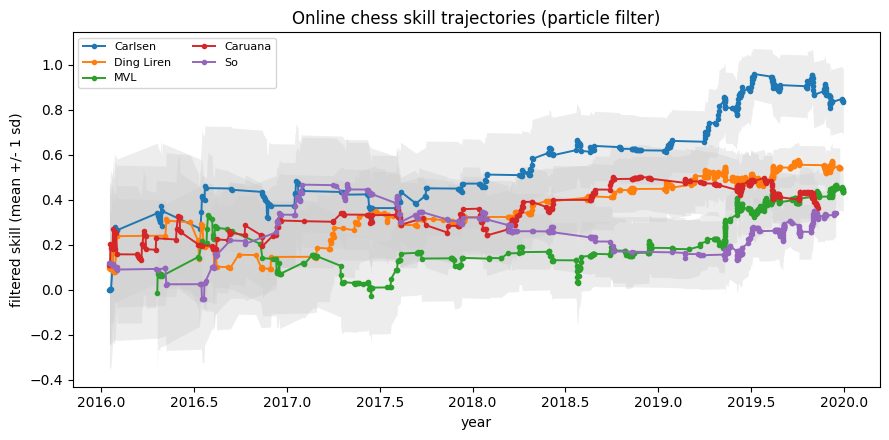

In [8]:
# per-game filtered skill trajectories (mean +/- 1 sd) from the recorded local-state sites
idx_np = np.asarray(match_idx)
times_np = np.asarray(match_times) / 365.25 + 2016.0  # calendar years (approx)

def trajectory(pid):
    ts, sk, sd = [], [], []
    for k in range(K):
        for slot in range(2):
            if idx_np[k, slot] == pid:
                ts.append(times_np[k]); sk.append(local_means[k, slot]); sd.append(local_stds[k, slot])
    return np.array(ts), np.array(sk), np.array(sd)

fig, ax = plt.subplots(figsize=(9, 4.5))
for pid in rank[:5]:
    ts, sk, sd = trajectory(pid)
    ax.fill_between(ts, sk - sd, sk + sd, color="0.8", alpha=0.35, lw=0)  # +/-1 sd, light grey
    ax.plot(ts, sk, marker="o", ms=3, lw=1.4, label=id_to_name[pid])
ax.set_xlabel("year"); ax.set_ylabel("filtered skill (mean +/- 1 sd)"); ax.legend(fontsize=8, ncol=2)
ax.set_title("Online chess skill trajectories (particle filter)")
plt.tight_layout(); plt.show()

## 7. Online performance on held-out matches

Using the **self-fitted parameters** from Part B, we replay the held-out test period one game at a time (each forecast uses only earlier games — genuine online operation). Below, for the most recent games, the probability the model assigned to the **actual** result, coloured green where the model's top pick (most-likely of white-win / draw / black-win) matched the result.


Held-out (test) online: accuracy 59.4%   NLL 0.976   over 1715 games


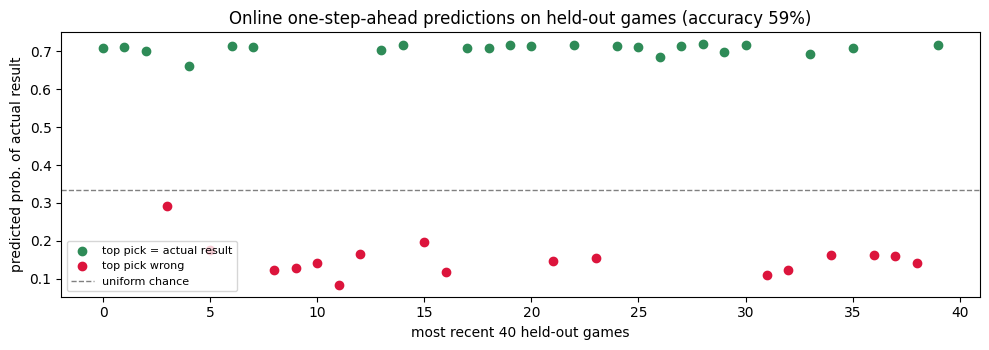

In [9]:
fit_params = map_params
pp_online = predict_probs(fit_params, FactorialPFConfig(n_particles=1000), key=jax.random.PRNGKey(1))
pred_label = np.asarray(pp_online).argmax(1)
actual = np.asarray(match_results)
correct = pred_label == actual
acc = correct[test_start:].mean()
print(f"Held-out (test) online: accuracy {acc*100:.1f}%   "
      f"NLL {win_nll(pp_online, test_start, K):.3f}   over {K - test_start} games")

N = 40
sl = slice(K - N, K)
p_act = np.asarray(pp_online)[np.arange(K), actual][sl]
cc = correct[sl]
x = np.arange(N)
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.scatter(x[cc], p_act[cc], c="seagreen", s=36, label="top pick = actual result", zorder=3)
ax.scatter(x[~cc], p_act[~cc], c="crimson", s=36, label="top pick wrong", zorder=3)
ax.axhline(1.0 / pp_online.shape[1], ls="--", c="gray", lw=1, label="uniform chance")
ax.set_xlabel(f"most recent {N} held-out games"); ax.set_ylabel("predicted prob. of actual result")
ax.set_title(f"Online one-step-ahead predictions on held-out games (accuracy {acc*100:.0f}%)")
ax.legend(fontsize=8, loc="lower left"); plt.tight_layout(); plt.show()

## 8. Discussion

- **Reproduction.** dynestyx's factorial EKF and particle filter reproduce Duffield et al.'s held-out chess NLL to within ~0.01–0.02 nats on the same data, using the same model (`MatchOutcomeObservation` = their Elo–Davidson SSM). The small EKF gap is the Laplace-update convention, not the model.
- **Method, not just numbers.** The dynestyx code is fully inference-agnostic: switching `FactorialEKFConfig` ↔ `FactorialPFConfig` swaps the EKF for a particle filter with no change to the model, and `dynestyx.contrib` turns the filter into held-out predictive NLL.
- **Chess specifics.** The 65% draw rate forces a large draw margin $\varepsilon$; skills drift slowly. See the companion `duffield_tennis_wta` (no draws) and `duffield_football_epl` (draws + a richer bivariate-Poisson scoreline model) notebooks.

> **Note on the factored approximation.** The factor-marginalized filter is *exact* on loop-free schedules and a tight approximation on cyclic ones (validated separately in the test suite); round-robin-heavy chess data is mildly cyclic, well within the regime where the approximation is accurate.
